# Loading data



In [1]:
import tensorflow as tf
import numpy as np
from tensorflow.keras import layers, models

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar100.load_data(label_mode='fine')

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

mean = np.mean(x_train, axis=(0, 1, 2))
std = np.std(x_train, axis=(0, 1, 2))

x_train = (x_train - mean) / (std + 1e-7)
x_test = (x_test - mean) / (std + 1e-7)


print(f"Träningsdata form: {x_train.shape}")
print(f"Antal klasser: {len(np.unique(y_train))}")

Träningsdata form: (50000, 32, 32, 3)
Antal klasser: 100


In [ ]:
from tensorflow.keras import optimizers
model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.Resizing(64, 64),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),

    # BLOCK 1: 2 st Conv-lager
    layers.Conv2D(64, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Conv2D(64, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.2),

    # BLOCK 2: 2 st Conv-lager
    layers.Conv2D(128, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Conv2D(128, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.3),

    # BLOCK 3: 2 st Conv-lager
    layers.Conv2D(256, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Conv2D(256, (3, 3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.4),

    # KLASSIFICERING
    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(100, activation='softmax')
])


model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
import numpy as np

def get_first_layer_filters(model):
    for layer in model.layers:
        if isinstance(layer, layers.Conv2D):
            weights, biases = layer.get_weights()
            return weights

filters_before = get_first_layer_filters(model)

In [6]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [ ]:


# Train model
history = model.fit(x_train, y_train, epochs=50, batch_size=64, validation_split=0.1, callbacks=[early_stop])

Epoch 1/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 89s 119ms/step - accuracy: 0.1208 - loss: 3.9150 - val_accuracy: 0.2004 - val_loss: 3.5358
Epoch 2/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 117ms/step - accuracy: 0.2312 - loss: 3.1396 - val_accuracy: 0.2628 - val_loss: 3.0045
Epoch 3/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 118ms/step - accuracy: 0.2982 - loss: 2.8025 - val_accuracy: 0.3602 - val_loss: 2.4872
Epoch 4/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 118ms/step - accuracy: 0.3379 - loss: 2.6043 - val_accuracy: 0.3940 - val_loss: 2.3080
Epoch 5/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 118ms/step - accuracy: 0.3693 - loss: 2.4414 - val_accuracy: 0.4324 - val_loss: 2.1107
Epoch 6/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 118ms/step - accuracy: 0.3915 - loss: 2.3237 - val_accuracy: 0.4392 - val_loss: 2.1110
Epoch 7/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 118ms/step - accuracy: 0.4170 - loss: 2.2231 - val_accuracy: 0.4774 - val_loss: 1.9493
Epoch 8/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 83s 118ms/step - accuracy: 0.4369 - loss: 2

In [ ]:
filters_after = get_first_layer_filters(model)

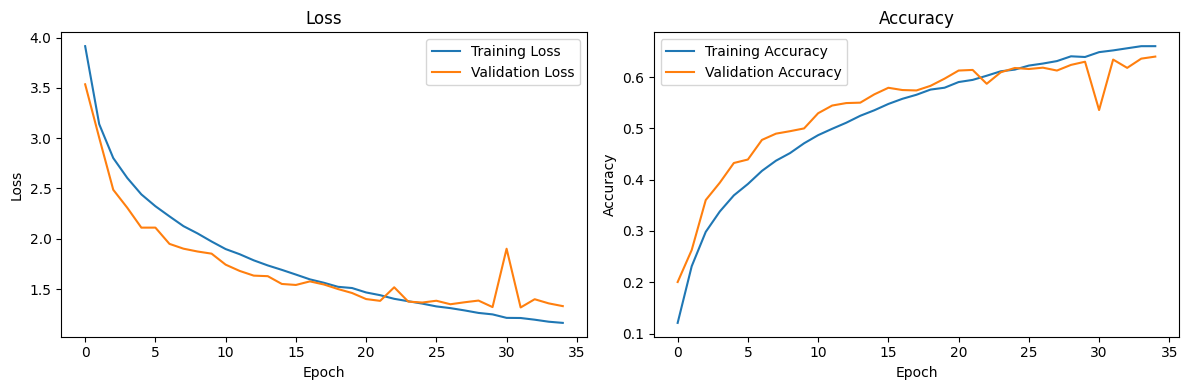

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
model.save('/content/drive/MyDrive/my_resnet_model.keras')

In [ ]:
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score
import pandas as pd
import numpy as np

y_pred_probs = model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test.flatten()

acc = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average='macro')
cm = confusion_matrix(y_true, y_pred)

TP = np.diag(cm).sum()
FP = cm.sum(axis=0) - np.diag(cm)
FN = cm.sum(axis=1) - np.diag(cm)
TN = []
for i in range(len(cm)):
    temp = np.delete(cm, i, 0)
    temp = np.delete(temp, i, 1)
    TN.append(sum(sum(temp)))

results_data = {
    "Metric": ["Accuracy", "F1-score", "TP", "TN (Total)", "FP (Total)", "FN (Total)"],
    "Value": [f"{acc:.4f}", f"{f1:.4f}", int(TP), int(np.sum(TN)), int(np.sum(FP)), int(np.sum(FN))]
}

df_results = pd.DataFrame(results_data)
print(df_results.to_string(index=False))

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step
    Metric  Value
  Accuracy 0.6421
  F1-score 0.6425
        TP   6421
TN (Total) 986421
FP (Total)   3579
FN (Total)   3579


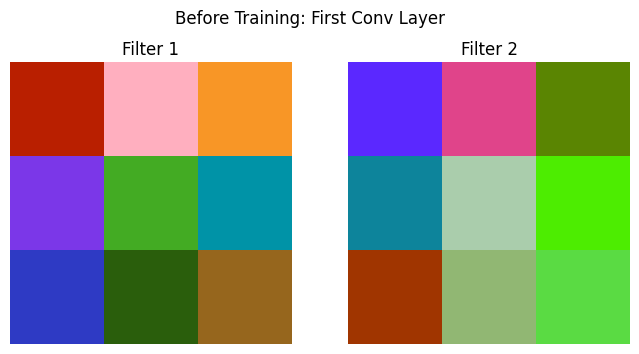

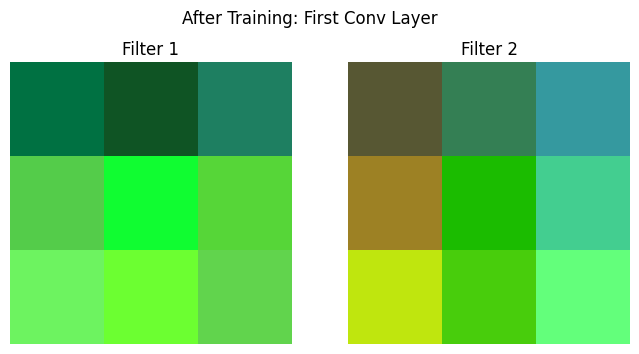

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_specific_layer_weights(model_to_use, title):
    target_layer = None
    for layer in model_to_use.layers:
        if 'conv2d' in layer.name.lower():
            target_layer = layer
            break

    if target_layer is None:
        print("No Conv2D layer found in the model!")
        return

    weights = target_layer.get_weights()
    filters = weights[0]


    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    fig.suptitle(title)

    for i in range(2):
        f = filters[:, :, :, i]

        f_min, f_max = f.min(), f.max()
        if f_max > f_min:
            f = (f - f_min) / (f_max - f_min)

        axes[i].imshow(f)
        axes[i].axis('off')
        axes[i].set_title(f'Filter {i+1}')
    plt.show()

plot_specific_layer_weights(old_model, "Before Training: First Conv Layer")
plot_specific_layer_weights(model, "After Training: First Conv Layer")

# ResNet-50

In [2]:
import tensorflow as tf
from tensorflow.keras import layers, models, applications

In [9]:
from tensorflow.keras.applications.resnet50 import preprocess_input
base_model = applications.ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(72, 72, 3)
)


# 2. Build the model
resnet_model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.UpSampling2D(size=(2, 2)),
    layers.Resizing(72, 72),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.5),
    layers.Dense(100, activation='softmax')
])

# 3. Compile
resnet_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Train
resnet_model.fit(x_train, y_train, epochs=50, batch_size=64, validation_split=0.1, callbacks=[early_stop])

Epoch 1/50
507/704 ━━━━━━━━━━━━━━━━━━━━ 35s 181ms/step - accuracy: 0.1713 - loss: 3.6779

KeyboardInterrupt: 

In [ ]:
from sklearn.metrics import confusion_matrix, f1_score, accuracy_score
import pandas as pd
import numpy as np

y_pred_probs = resnet_model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test.flatten()

acc = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average='macro')
cm = confusion_matrix(y_true, y_pred)

TP = np.diag(cm).sum()
FP = cm.sum(axis=0) - np.diag(cm)
FN = cm.sum(axis=1) - np.diag(cm)
TN = []
for i in range(len(cm)):
    temp = np.delete(cm, i, 0)
    temp = np.delete(temp, i, 1)
    TN.append(sum(sum(temp)))

results_data = {
    "Metric": ["Accuracy", "F1-score", "TP", "TN (Total)", "FP (Total)", "FN (Total)"],
    "Value": [f"{acc:.4f}", f"{f1:.4f}", int(TP), int(np.sum(TN)), int(np.sum(FP)), int(np.sum(FN))]
}

df_results = pd.DataFrame(results_data)
print(df_results.to_string(index=False))

313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 33ms/step
    Metric  Value
  Accuracy 0.5473
  F1-score 0.5457
        TP   5473
TN (Total) 985473
FP (Total)   4527
FN (Total)   4527


In [3]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

# VGG-19

In [6]:
from tensorflow.keras.applications.vgg19 import preprocess_input
base_vgg = applications.VGG19(weights='imagenet', include_top=False, input_shape=(72, 72, 3))
base_vgg.trainable = False

vgg_model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.UpSampling2D(size=(2, 2)),
    layers.Resizing(72, 72),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    base_vgg,
    layers.GlobalAveragePooling2D(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(100, activation='softmax')
])

vgg_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

vgg_model.fit(x_train, y_train, epochs=50, batch_size=64, validation_split=0.1, callbacks=[early_stop])

Epoch 1/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 39s 51ms/step - accuracy: 0.2282 - loss: 3.2142 - val_accuracy: 0.3716 - val_loss: 2.4719
Epoch 2/50
 87/704 ━━━━━━━━━━━━━━━━━━━━ 28s 46ms/step - accuracy: 0.3183 - loss: 2.6684

KeyboardInterrupt: 

In [ ]:
y_pred_probs = vgg_model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test.flatten()

acc = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average='macro')
cm = confusion_matrix(y_true, y_pred)

TP = np.diag(cm).sum()
FP = cm.sum(axis=0) - np.diag(cm)
FN = cm.sum(axis=1) - np.diag(cm)
TN = []
for i in range(len(cm)):
    temp = np.delete(cm, i, 0)
    temp = np.delete(temp, i, 1)
    TN.append(sum(sum(temp)))

results_data = {
    "Metric": ["Accuracy", "F1-score", "TP", "TN (Total)", "FP (Total)", "FN (Total)"],
    "Value": [f"{acc:.4f}", f"{f1:.4f}", int(TP), int(np.sum(TN)), int(np.sum(FP)), int(np.sum(FN))]
}

df_results = pd.DataFrame(results_data)
print(df_results.to_string(index=False))

313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 43ms/step
    Metric  Value
  Accuracy 0.0507
  F1-score 0.0214
        TP    507
TN (Total) 980507
FP (Total)   9493
FN (Total)   9493


# DenseNet-121

In [4]:
from tensorflow.keras.applications.densenet import preprocess_input
base_densenet = applications.DenseNet121(weights='imagenet', include_top=False, input_shape=(72, 72, 3))

base_densenet.trainable = False

densenet_model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.UpSampling2D(size=(2, 2)),
    layers.Resizing(72, 72),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    base_densenet,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.4),
    layers.Dense(100, activation='softmax')
])

densenet_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

densenet_model.fit(x_train, y_train, epochs=50, batch_size=64, validation_split=0.1, callbacks=[early_stop])

Epoch 1/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 55s 53ms/step - accuracy: 0.2752 - loss: 4.2056 - val_accuracy: 0.4798 - val_loss: 2.0955
Epoch 2/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 32s 46ms/step - accuracy: 0.4149 - loss: 2.6362 - val_accuracy: 0.5020 - val_loss: 1.9268
Epoch 3/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 32s 45ms/step - accuracy: 0.4413 - loss: 2.3999 - val_accuracy: 0.5102 - val_loss: 1.8565
Epoch 4/50
649/704 ━━━━━━━━━━━━━━━━━━━━ 2s 40ms/step - accuracy: 0.4591 - loss: 2.2683

KeyboardInterrupt: 

In [ ]:
y_pred_probs = densenet_model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test.flatten()

acc = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average='macro')
cm = confusion_matrix(y_true, y_pred)

TP = np.diag(cm).sum()
FP = cm.sum(axis=0) - np.diag(cm)
FN = cm.sum(axis=1) - np.diag(cm)
TN = []
for i in range(len(cm)):
    temp = np.delete(cm, i, 0)
    temp = np.delete(temp, i, 1)
    TN.append(sum(sum(temp)))

results_data = {
    "Metric": ["Accuracy", "F1-score", "TP", "TN (Total)", "FP (Total)", "FN (Total)"],
    "Value": [f"{acc:.4f}", f"{f1:.4f}", int(TP), int(np.sum(TN)), int(np.sum(FP)), int(np.sum(FN))]
}

df_results = pd.DataFrame(results_data)
print(df_results.to_string(index=False))

313/313 ━━━━━━━━━━━━━━━━━━━━ 35s 64ms/step
    Metric  Value
  Accuracy 0.5676
  F1-score 0.5651
        TP   5676
TN (Total) 985676
FP (Total)   4324
FN (Total)   4324


# EfficientNet-B0

In [33]:
from tensorflow.keras.applications.efficientnet import preprocess_input
base_efficientnet = applications.EfficientNetB0(weights='imagenet', include_top=False, input_shape=(72, 72, 3))

efficient_model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.UpSampling2D(size=(2, 2)),
    layers.Resizing(72, 72),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.Lambda(lambda x: preprocess_input(x * 255.0)),
    base_efficientnet,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(100, activation='softmax')
])

efficient_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

efficient_model.fit(x_train, y_train, epochs=50, batch_size=64, validation_split=0.1, callbacks=[early_stop])

Epoch 1/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 125s 118ms/step - accuracy: 0.4838 - loss: 1.9557 - val_accuracy: 0.6164 - val_loss: 1.3864
Epoch 2/50
704/704 ━━━━━━━━━━━━━━━━━━━━ 138s 113ms/step - accuracy: 0.6418 - loss: 1.2516 - val_accuracy: 0.6624 - val_loss: 1.1798
Epoch 3/50
138/704 ━━━━━━━━━━━━━━━━━━━━ 1:04 114ms/step - accuracy: 0.7015 - loss: 0.9907

KeyboardInterrupt: 

In [ ]:
y_pred_probs = efficient_model.predict(x_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test.flatten()

acc = accuracy_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred, average='macro')
cm = confusion_matrix(y_true, y_pred)

TP = np.diag(cm).sum()
FP = cm.sum(axis=0) - np.diag(cm)
FN = cm.sum(axis=1) - np.diag(cm)
TN = []
for i in range(len(cm)):
    temp = np.delete(cm, i, 0)
    temp = np.delete(temp, i, 1)
    TN.append(sum(sum(temp)))

results_data = {
    "Metric": ["Accuracy", "F1-score", "TP", "TN (Total)", "FP (Total)", "FN (Total)"],
    "Value": [f"{acc:.4f}", f"{f1:.4f}", int(TP), int(np.sum(TN)), int(np.sum(FP)), int(np.sum(FN))]
}

df_results = pd.DataFrame(results_data)
print(df_results.to_string(index=False))

313/313 ━━━━━━━━━━━━━━━━━━━━ 30s 53ms/step
    Metric  Value
  Accuracy 0.1760
  F1-score 0.1717
        TP   1760
TN (Total) 981760
FP (Total)   8240
FN (Total)   8240
